#	Exercise 1: Compute autocorrelation

**Step 1**: Generate the Chain: Reuse your Metropolis-Hastings code from the previous assignment to generate a chain of 
 samples.

**Step 2**: Compute Errors:

*	Calculate the **standard deviation** $\sigma_{y}$ and the **naive error** $ \dfrac{\sigma_{y}}{\sqrt{N}} $.

*	Calculate the **autocovariance**
$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$
*	Calculate the **integrated autocorelation time** 
$$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$
and the **corrected error**

$$ \sigma_{\overline{y}} = \dfrac{1}{\sqrt{N}} \sigma_{y} \times \sqrt{2\tau_{int}}$$
<!-- 
where $$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$$

$$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $$ -->
**Step 3** Visualization: Plot the normalized autocorrelation function $\rho(t)$ against lag t
$$\rho(t) = \dfrac{C_y(t)}{C_y(0)}$$

**Questions**:
- What does it mean if $\rho(t)$ stays high for a long time (large t)?
- If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
- How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?


In [128]:
import numpy as np
from matplotlib import pyplot as plt

## Step 1

In [129]:
# --- PARAMETERS ---
sigma = 1.0
steps = 50000
step_size = 1.0


# gausian bell function
def P(x):
    return np.exp(-x ** 2 / (2 * sigma ** 2))


# --- METHOD 1 ---
current_point = 0.0
distribution = [current_point]

for step in range(steps-1):
    # selecting candidate
    candidate_point = current_point + np.random.normal(0, step_size)

    # random acceptence to compare
    p = np.random.rand()

    # accept-reject metod (Metropolis)
    if p <= min(1, P(candidate_point) / P(current_point)):
        distribution.append(candidate_point)
        current_point = candidate_point
    else:
        distribution.append(current_point)

distribution_uncorrelated = np.array(distribution)

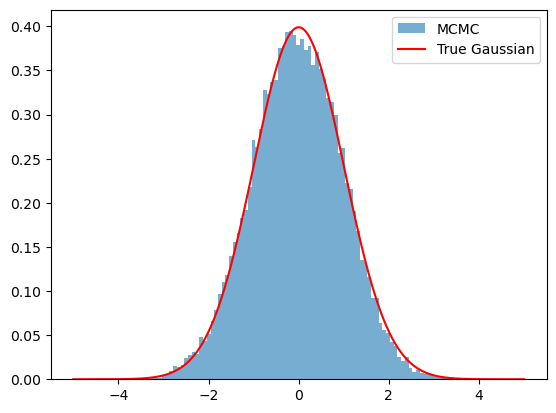

In [130]:
# plotting the histogram of out states (aka distribution)
plt.hist(distribution, bins=100, density=True, alpha=0.6, label="MCMC")

# plotting true gausian
x_vals = np.linspace(-5, 5, 500)
y_vals = P(x_vals)
# nnormalizing the plot
y_vals /= np.trapz(y_vals, x_vals)
plt.plot(x_vals, y_vals, 'r', label="True Gaussian")

plt.legend()
plt.show()

50000
10000
2000


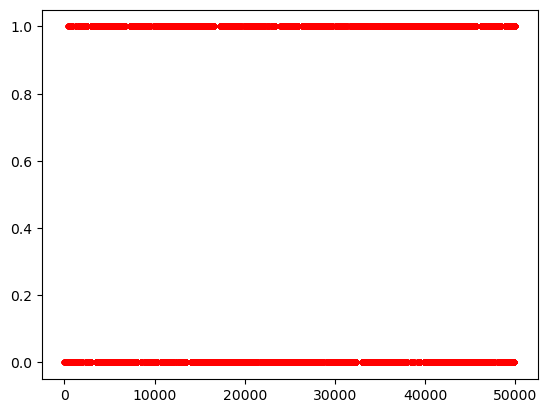

In [131]:
# also for test distribution 2 from lectures with high autocorrelation
def generate_correlated_distro(length):
    T = [[0.99,0.01],
         [0.01,0.99]]
    n_states = 2
    states = np.arange(n_states)

    current_state = 0
    history = [current_state]

    n_steps = length
    for _ in range(n_steps-1):
        current_state = np.random.choice(a = states, p = T[current_state])
        history.append(current_state)

    print(len(history))
    return np.array(history)

distribution_correlated = generate_correlated_distro(50000)
distribution_correlated2 = generate_correlated_distro(10000)
distribution_correlated3 = generate_correlated_distro(2000)
plt.scatter(np.arange(len(distribution_correlated)),distribution_correlated, marker='.', c='r')
plt.show()

## Step 2

### **naive error**
$ \dfrac{\sigma_{y}}{\sqrt{N}} $

In [132]:
def naive_std_err(y):
    return np.std(y, ddof=1)/np.sqrt(len(y))

### **autocovariance**
$C_y(t)  =(1-\dfrac{t}{N})\bigl( \langle y_i y_{i+t} \rangle - \langle y_i \rangle  \langle y_{i+t}\rangle\bigr) \approx (1-\dfrac{t}{N})\langle (y_i - \overline{y})( y_{i+t} - \overline{y}) \rangle $

In [133]:
def auto_covariance(t, y):
    n = len(y)
    if t >= n:
        return 0

    mean = np.mean(y)
    data_centered = y - mean

    cov = np.dot(data_centered[:n-t], data_centered[t:]) / (n - t)
    return (1 - t/n) * cov

### **integrated autocorelation time**
$ \tau_{int} = \dfrac{1}{2} + \sum_{t=1}^{N-1} \dfrac{C_y(t)}{C_y(0)}.$

In [134]:
def auto_correlation(y, t_max = None):
    C_0 = auto_covariance(0,y)
    N = len(y)
    t_max = t_max if t_max else N//2

    return max(0.5 + np.sum([(auto_covariance(t,y)/C_0) for t in range(1,t_max)]), 0.5)

### **corrected error**:
$ \sigma_{\overline{y}} = \dfrac{1}{\sqrt{N}} \sigma_{y} \times \sqrt{2\tau_{int}}$

In [135]:
def corrected_error(y):
    N = len(y)
    sigma = np.std(y, ddof=1)

    tau = auto_correlation(y)
    tau = max(tau, 0.5)

    return (sigma/np.sqrt(N)) * np.sqrt(2 * tau)

### Benchmarking

In [136]:
def benchmark_distro(distribution, title=""):
    naive_err = naive_std_err(distribution)
    auto_cov = auto_covariance(20,distribution)
    auto_corr = auto_correlation(distribution)
    corr_error = corrected_error(distribution)

    print_title = f"     BENCHMARK FOR {title}     "
    print("="*len(print_title))
    print(print_title)
    print("="*len(print_title))
    print(f"Naive Error: {naive_err}")
    print(f"Auto Covariance for t=20: {auto_cov}")
    print(f"Auto Correlation: {auto_corr}")
    print(f"Corrected Error: {corr_error}")
    print("="*len(print_title), end='\n\n')

In [137]:
benchmark_distro(distribution_uncorrelated, title="Un-Correlated Distro")
benchmark_distro(distribution_correlated2, title="Correlated Distro")

     BENCHMARK FOR Un-Correlated Distro     
Naive Error: 0.004451706588791383
Auto Covariance for t=20: 0.010966476658298925
Auto Correlation: 1.7562274316670359
Corrected Error: 0.008343185667015668

     BENCHMARK FOR Correlated Distro     
Naive Error: 0.004977443972045239
Auto Covariance for t=20: 0.15112475941999418
Auto Correlation: 7.968849645639999
Corrected Error: 0.019870975795563264



## Step 3

Plot the normalized autocorrelation function $\rho(t)$ against lag t:

$$\rho(t) = \dfrac{C_y(t)}{C_y(0)}$$

In [138]:
def plot_autocorrelation(distribution, title="", t_max=None):
    N = len(distribution)

    C_0 = auto_covariance(0,distribution)

    p_t = []
    t_max = t_max if t_max else N
    t_values = np.arange(0,t_max)
    for t in t_values:
        auto_cor = auto_covariance(t, distribution)/C_0
        p_t.append(auto_cor)

    plt.xlabel("lag t")
    plt.ylabel("p_t (auto corr)")
    plt.hlines(y=0,xmin=0, xmax=t_max, linestyle='dashed', color='r')
    plt.title(title)
    plt.plot(t_values, p_t)
    plt.show()

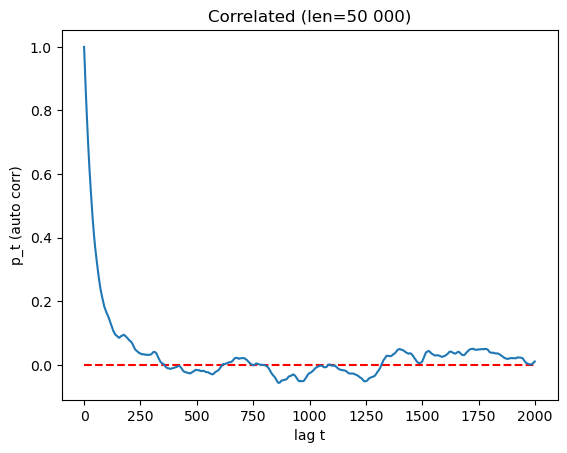

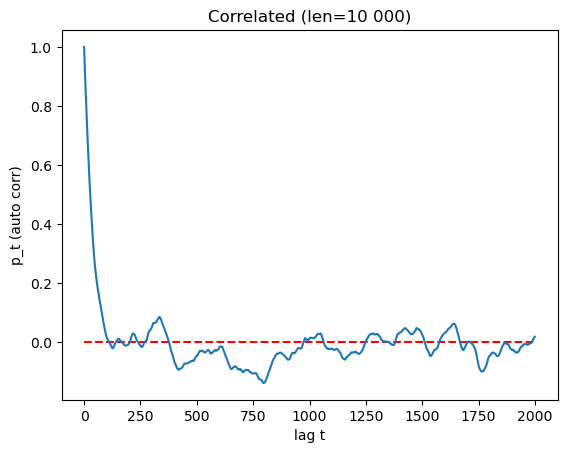

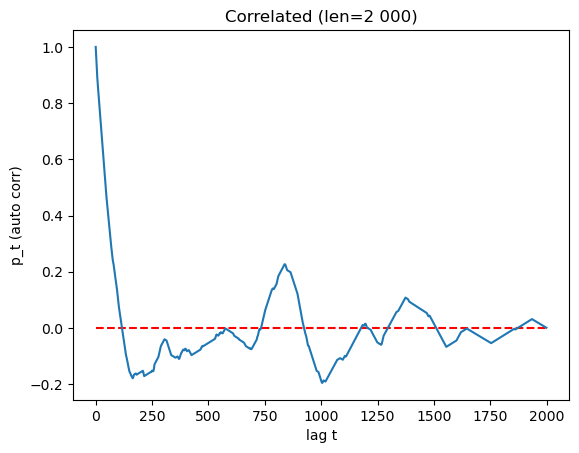

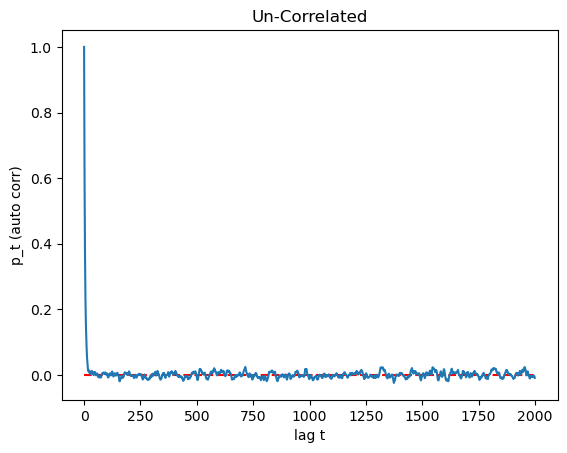

In [139]:
t_max = min(len(distribution_correlated), len(distribution_correlated2), len(distribution_correlated3), len(distribution_uncorrelated))
plot_autocorrelation(distribution_correlated, title="Correlated (len=50 000)", t_max=t_max)
plot_autocorrelation(distribution_correlated2, title="Correlated (len=10 000)", t_max=t_max)
plot_autocorrelation(distribution_correlated3, title="Correlated (len=2 000)", t_max=t_max)
plot_autocorrelation(distribution_uncorrelated, title="Un-Correlated", t_max=t_max)

**Questions**:
1. What does it mean if $\rho(t)$ stays high for a long time (large t)?
2. If your chain has 100000 steps and $\tau_{int} = 50$, how many "independent" data points have you actually collected?
3. How would increasing the proposal step size in your Metropolis algorithm likely change the shape of the $C_y(t)$ plot?

**Answers:**

1. This means the chain has a "long memory." Successive samples are strongly correlated, which practically means the chain is stuck in one region of the state space and explores it very slowly.
2. Effectively, we get $N_{eff} = \frac{N}{2 \tau_{int}}$, which results in $\frac{100,000}{2 \cdot 50} = 1000$. (i know somethimes people use $N_{eff} = \frac{N}{\tau_{int}}$ but i will stick to that formula)
3. This is the classic "Goldilocks" problem—finding the optimal step size to ensure efficient state space exploration:
    - **Step size too small:** We accept moves almost every time, but the moves are so tiny that the chain barely moves. Consequently, $C_y(t)$ decays very slowly, leading to high autocorrelation.
    - **Optimal step size:** We achieve a balance where the chain moves significantly and $C_y(t)$ decays rapidly, resulting in low autocorrelation. (optimal acceptance for metropolis is about 23%)
    - **Step size too large:** We propose moves that are too far from the current state, often landing in low-probability regions. This leads to frequent rejections, the chain stands still too often, and $C_y(t)$ again decays very slowly.